In [1]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    recall_score,
    precision_score,
    f1_score
)


warnings.filterwarnings('ignore')

# Optional: SMOTE (imbalanced-learn). If not installed, the script will continue without it.
use_smote = True
try:
    from imblearn.over_sampling import SMOTE
except Exception:
    use_smote = False
    print("imblearn.SMOTE not available. To use SMOTE install imbalanced-learn (pip install imbalanced-learn).")

In [2]:
# Load dataset
file_path = r"../../datasets/bank-additional/bank-additional-full.csv"
try:
    df = pd.read_csv(file_path, sep=';')
    print(f"Loaded dataset from: {file_path}")
except Exception:
    url = "https://raw.githubusercontent.com/mkhazaeidev/DataMiningTutorial/main/datasets/bank-additional/bank-additional-full.csv"
    df = pd.read_csv(url, sep=';')
    print("Downloaded dataset from fallback URL.")


print('\nShape:', df.shape)

Loaded dataset from: ../../datasets/bank-additional/bank-additional-full.csv

Shape: (41188, 21)


In [3]:
# Quick cleanup and target encoding

df['y'] = df['y'].map({'yes': 1, 'no': 0})

# Drop rows with missing values if any (dataset is mostly clean)
if df.isnull().sum().sum() > 0:
    print('Dropping rows with missing values...')
    df = df.dropna()

# Features and target
X = df.drop(columns=['y'])
y = df['y']

# Split - stratify to keep class balance
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print('\nTrain shape:', X_train.shape, 'Test shape:', X_test.shape)


Train shape: (32950, 20) Test shape: (8238, 20)


In [6]:
# Preprocessing: identify numeric and categorical

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X.select_dtypes(include=['object']).columns.tolist()

print('\nNumeric features:', numeric_features)
print('Categorical features:', cat_features)

# ColumnTransformer: OneHot for categorical, passthrough numeric (DecisionTree doesn't need scaling)
preprocessor_tree = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
        ('num', 'passthrough', numeric_features)
    ],
    remainder='drop'
)

# For Logistic Regression we'll build a different pipeline (with scaling)
preprocessor_logreg = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
        ('num', StandardScaler(), numeric_features)
    ],
    remainder='drop'
)


Numeric features: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


In [7]:
# Baseline Decision Tree (no tuning)

baseline_pipe = Pipeline(steps=[('pre', preprocessor_tree), ('clf', DecisionTreeClassifier(random_state=42))])
baseline_pipe.fit(X_train, y_train)

# Predictions
y_pred_train = baseline_pipe.predict(X_train)
y_pred_test = baseline_pipe.predict(X_test)

print('\nBaseline Decision Tree performance:')
print('Train accuracy:', accuracy_score(y_train, y_pred_train))
print('Test accuracy :', accuracy_score(y_test, y_pred_test))
print('\nClassification report (test):')
print(classification_report(y_test, y_pred_test, digits=4))
print('Confusion matrix (test):\n', confusion_matrix(y_test, y_pred_test))

# Check overfitting
train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)
if train_acc - test_acc > 0.05:
    print('\nWarning: possible overfitting (train_acc - test_acc > 0.05). Consider pruning/tuning.')


Baseline Decision Tree performance:
Train accuracy: 1.0
Test accuracy : 0.894634620053411

Classification report (test):
              precision    recall  f1-score   support

           0     0.9407    0.9405    0.9406      7310
           1     0.5323    0.5334    0.5328       928

    accuracy                         0.8946      8238
   macro avg     0.7365    0.7369    0.7367      8238
weighted avg     0.8947    0.8946    0.8947      8238

Confusion matrix (test):
 [[6875  435]
 [ 433  495]]



In [8]:
# Handling imbalance (optional): SMOTE on training set

if use_smote:
    print('\nApplying SMOTE to training data...')
    # Need numeric matrix after preprocessing to apply SMOTE. We transform then apply.
    X_train_pre = preprocessor_tree.fit_transform(X_train)
    sm = SMOTE(random_state=42)
    X_res, y_res = sm.fit_resample(X_train_pre, y_train.values)
    print('After SMOTE, class counts:', np.bincount(y_res))
else:
    X_train_pre = preprocessor_tree.fit_transform(X_train)
    X_res, y_res = X_train_pre, y_train.values


Applying SMOTE to training data...
After SMOTE, class counts: [29238 29238]


In [9]:
# Hyperparameter tuning for DecisionTree

# If SMOTE was used, we must fit on the preprocessed array. We'll create a classifier and grid search manually.
param_grid = {
    'max_depth': [3, 5, 7, 9, None],
    'min_samples_split': [2, 10, 20, 50],
    'min_samples_leaf': [1, 5, 10, 20],
    'max_leaf_nodes': [None, 10, 20, 50]
}

# Create a DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)

# If we used SMOTE we already preprocessed; otherwise use pipeline and GridSearchCV with pipeline
if use_smote:
    # GridSearch on raw estimator using preprocessed X_res
    grid = GridSearchCV(estimator=dt, param_grid=param_grid, scoring='recall', cv=5, n_jobs=-1, verbose=1)
    grid.fit(X_res, y_res)
    best_dt = grid.best_estimator_
    print('\nBest params (SMOTE + GridSearch):', grid.best_params_)
else:
    # Build pipeline so preprocessing is inside CV
    pipe = Pipeline(steps=[('pre', preprocessor_tree), ('clf', dt)])
    grid = GridSearchCV(estimator=pipe, param_grid={
    'clf__' + k: v for k, v in param_grid.items()
    }, scoring='recall', cv=5, n_jobs=-1, verbose=1)
    grid.fit(X_train, y_train)
    best_dt = grid.best_estimator_
    print('\nBest params (Pipeline GridSearch):', grid.best_params_)

Fitting 5 folds for each of 320 candidates, totalling 1600 fits

Best params (SMOTE + GridSearch): {'max_depth': 3, 'max_leaf_nodes': None, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [10]:
# Final evaluation on test set

print('\nEvaluating best model on test set...')


if use_smote:
    # need to transform X_test with preprocessor_tree
    X_test_pre = preprocessor_tree.transform(X_test)
    y_test_pred = best_dt.predict(X_test_pre)
else:
    y_test_pred = best_dt.predict(X_test)


print('Test accuracy :', accuracy_score(y_test, y_test_pred))
print('Test recall :', recall_score(y_test, y_test_pred))
print('Test precision:', precision_score(y_test, y_test_pred))
print('Test f1-score :', f1_score(y_test, y_test_pred))
print('\nClassification report (test):')
print(classification_report(y_test, y_test_pred, digits=4))
print('Confusion matrix (test):\n', confusion_matrix(y_test, y_test_pred))


Evaluating best model on test set...
Test accuracy : 0.755887351298859
Test recall : 0.9245689655172413
Test precision: 0.3065380493033226
Test f1-score : 0.46042393345854576

Classification report (test):
              precision    recall  f1-score   support

           0     0.9871    0.7345    0.8423      7310
           1     0.3065    0.9246    0.4604       928

    accuracy                         0.7559      8238
   macro avg     0.6468    0.8295    0.6513      8238
weighted avg     0.9105    0.7559    0.7992      8238

Confusion matrix (test):
 [[5369 1941]
 [  70  858]]



Top 15 important features:
duration             0.478750
nr.employed          0.327427
contact_telephone    0.108958
cons.conf.idx        0.084865
job_admin.           0.000000
job_blue-collar      0.000000
job_entrepreneur     0.000000
job_services         0.000000
job_student          0.000000
job_technician       0.000000
job_unemployed       0.000000
job_housemaid        0.000000
job_management       0.000000
job_retired          0.000000
job_self-employed    0.000000
dtype: float64


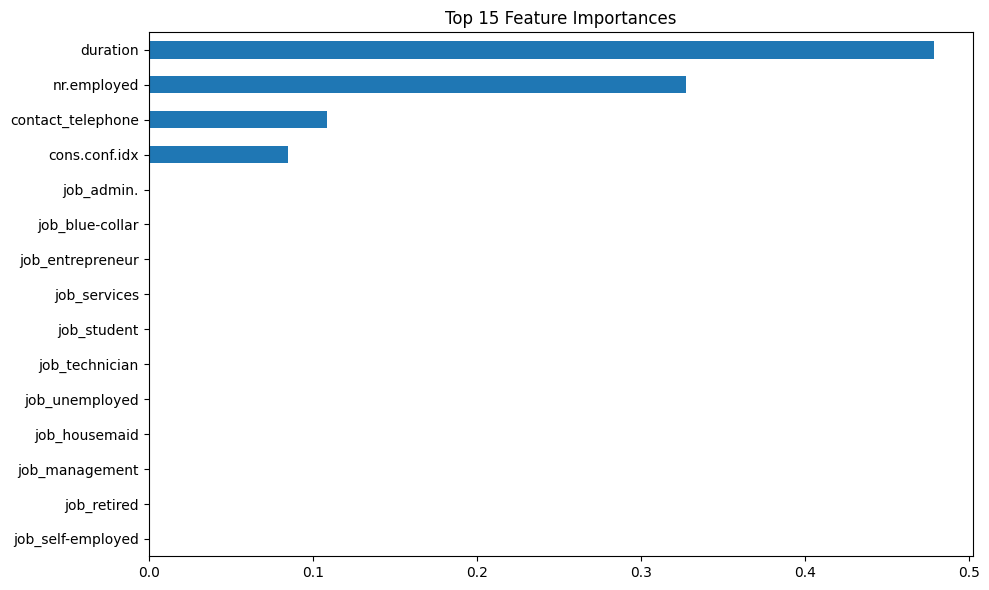

In [11]:
# Feature importances (map back to original feature names)

# We need feature names after OneHot encoding
# Use the preprocessor fitted earlier to get feature names
if use_smote:
    # preprocessor_tree was already fitted on X_train
    ohe = preprocessor_tree.named_transformers_['cat']
    cat_names = ohe.get_feature_names_out(cat_features)
    feature_names = list(cat_names) + numeric_features
    importances = best_dt.feature_importances_
else:
# best_dt is a pipeline
    ohe = best_dt.named_steps['pre'].named_transformers_['cat']
    cat_names = ohe.get_feature_names_out(cat_features)
    feature_names = list(cat_names) + numeric_features
    importances = best_dt.named_steps['clf'].feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)
print('\nTop 15 important features:')
print(feat_imp.head(15))

# Plot top features
plt.figure(figsize=(10, 6))
feat_imp.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importances')
plt.tight_layout()
plt.show()

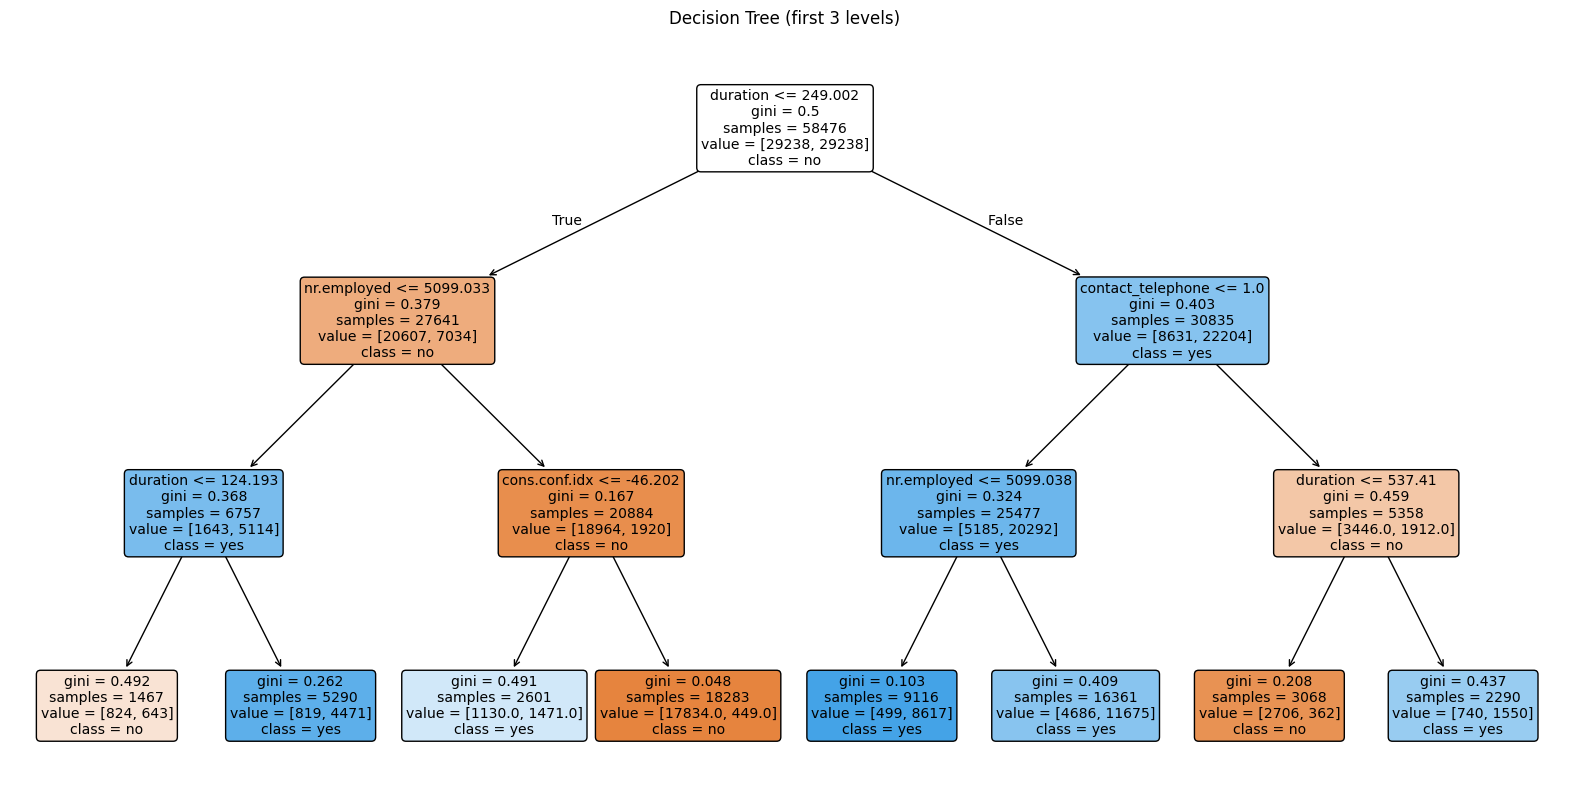

In [12]:
# Tree visualization (shallow) for interpretability

plt.figure(figsize=(20, 10))
# choose the estimator object depending on pipeline or raw estimator
if use_smote:
    estimator_to_plot = best_dt
else:
    estimator_to_plot = best_dt.named_steps['clf']

# For plotting, use the feature names we computed and limit depth
plot_tree(estimator_to_plot, feature_names=feature_names, class_names=['no', 'yes'], max_depth=3, filled=True, rounded=True)
plt.title('Decision Tree (first 3 levels)')
plt.show()

In [13]:
# Compare with Logistic Regression

logreg_pipe = Pipeline(steps=[('pre', preprocessor_logreg), ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))])
logreg_pipe.fit(X_train, y_train)

y_log_pred = logreg_pipe.predict(X_test)
print('\nLogistic Regression (with class_weight=balanced) performance:')
print('Accuracy:', accuracy_score(y_test, y_log_pred))
print('Recall :', recall_score(y_test, y_log_pred))
print('Precision:', precision_score(y_test, y_log_pred))
print('\nClassification report (logreg, test):')
print(classification_report(y_test, y_log_pred, digits=4))


Logistic Regression (with class_weight=balanced) performance:
Accuracy: 0.8651371692158291
Recall : 0.9116379310344828
Precision: 0.4512

Classification report (logreg, test):
              precision    recall  f1-score   support

           0     0.9871    0.8592    0.9187      7310
           1     0.4512    0.9116    0.6036       928

    accuracy                         0.8651      8238
   macro avg     0.7192    0.8854    0.7612      8238
weighted avg     0.9267    0.8651    0.8832      8238



In [14]:
# Save best model (optional)
try:
    import joblib
    if use_smote:
        joblib.dump({'preprocessor': preprocessor_tree, 'estimator': best_dt}, 'best_decision_tree_smote.joblib')
        print('\nSaved model to best_decision_tree_smote.joblib')
    else:
        joblib.dump(best_dt, 'best_decision_tree_pipeline.joblib')
        print('\nSaved pipeline to best_decision_tree_pipeline.joblib')
except Exception:
    print('\njoblib not available or save failed. Install joblib to enable model saving.')

print('\n--- End of script ---')


Saved model to best_decision_tree_smote.joblib

--- End of script ---
